In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 100)
pd.set_option('display.float_format', lambda x: '%.6f' % x)

DATA_PATH = Path("./semiconductor_yield.csv")

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")

Dataset loaded successfully.


# Semiconductor Process Characterization

## Objective

Characterize the observed wafer-level manufacturing variables.

Process flow:

Lithography → Etch → Deposition → Implant →
Metrology → Defect Inspection → Electrical Test → Yield

In [2]:
lithography_vars = [
    "exposure_time",
    "focus_offset"
]

litho = df[lithography_vars].copy()

litho.head()

,exposure_time,focus_offset
0,1.576151,0.019829
1,1.627974,0.022971
2,1.508568,0.020422
3,1.491113,0.018948
4,1.400622,0.019902


In [3]:
litho_summary = litho.describe(
    percentiles=[
        0.01,
        0.05,
        0.10,
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
        0.99
    ]
).T

litho_summary["IQR"] = (
    litho_summary["75%"]
    - litho_summary["25%"]
)

litho_summary["CV_pct"] = (
    litho_summary["std"]
    / litho_summary["mean"].abs()
    * 100
)

litho_summary

,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max,IQR,CV_pct
exposure_time,1250.000000,1.501329,0.049894,1.350315,1.379489,1.418879,1.436646,1.467451,1.501331,1.534600,1.567455,1.581328,1.608187,1.670403,0.067149,3.323320
focus_offset,1250.000000,0.027446,0.006700,0.008577,0.013108,0.016835,0.019034,0.022930,0.026975,0.031890,0.036002,0.039041,0.044140,0.051468,0.008960,24.410484


In [4]:
litho_summary["skewness"] = litho.skew()

litho_summary[
    [
        "count",
        "mean",
        "50%",
        "std",
        "IQR",
        "CV_pct",
        "skewness",
        "min",
        "max"
    ]
]

,count,mean,50%,std,IQR,CV_pct,skewness,min,max
exposure_time,1250.000000,1.501329,1.501331,0.049894,0.067149,3.323320,-0.032125,1.350315,1.670403
focus_offset,1250.000000,0.027446,0.026975,0.006700,0.008960,24.410484,0.213699,0.008577,0.051468


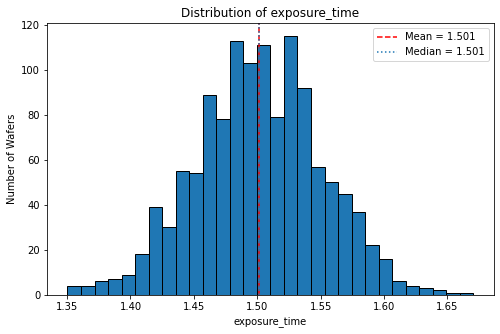

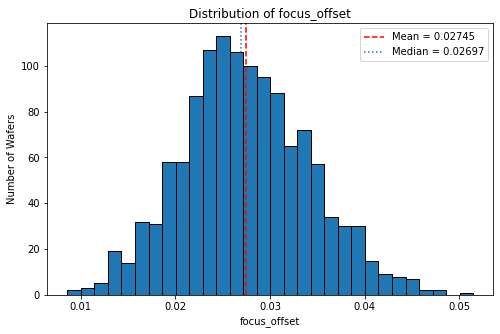

In [5]:
import matplotlib.pyplot as plt

for col in lithography_vars:
    plt.figure(figsize=(8, 5))

    plt.hist(
        df[col].dropna(),
        bins=30,
        edgecolor="black"
    )

    plt.axvline(
        df[col].mean(),
        linestyle="--",
        color='red',
        label=f"Mean = {df[col].mean():.4g}"
    )

    plt.axvline(
        df[col].median(),
        linestyle=":",
        label=f"Median = {df[col].median():.4g}"
    )

    plt.xlabel(col)
    plt.ylabel("Number of Wafers")
    plt.title(f"Distribution of {col}")
    plt.legend()

    plt.show()


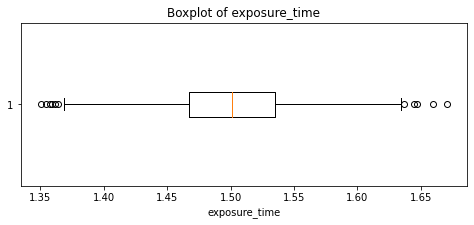

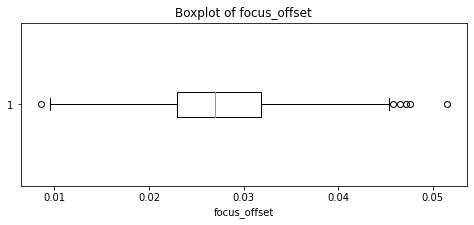

In [6]:
for col in lithography_vars:
    plt.figure(figsize=(8, 3))

    plt.boxplot(
        df[col].dropna(),
        vert=False
    )

    plt.xlabel(col)
    plt.title(f"Boxplot of {col}")

    plt.show()

## Lithography


In [7]:
litho_outlier_summary = []

for col in lithography_vars:

    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    flag = (
        (df[col] < lower)
        | (df[col] > upper)
    )

    litho_outlier_summary.append({
        "variable": col,
        "lower_iqr_fence": lower,
        "upper_iqr_fence": upper,
        "flagged_wafers": flag.sum(),
        "flagged_pct": flag.mean() * 100
    })

litho_outlier_summary = pd.DataFrame(
    litho_outlier_summary
)

litho_outlier_summary

,variable,lower_iqr_fence,upper_iqr_fence,flagged_wafers,flagged_pct
0,exposure_time,1.366727,1.635324,11,0.880000
1,focus_offset,0.009490,0.045330,6,0.480000


In [8]:
for col in lithography_vars:

    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    flagged = df[
        (df[col] < lower)
        | (df[col] > upper)
    ][
        [
            "lot_id",
            "wafer_id",
            "product_type",
            "technology_node",
            "litho_tool",
            col
        ]
    ]

    print(f"\n{col}: {len(flagged)} flagged wafers")
    display(flagged.head(10))


exposure_time: 11 flagged wafers


,lot_id,wafer_id,product_type,technology_node,litho_tool,exposure_time
9,LOT_0001,W010,CPU,10nm,LITHO_01,1.636721
82,LOT_0004,W008,GPU,14nm,LITHO_01,1.659655
189,LOT_0008,W015,CPU,10nm,LITHO_01,1.363886
214,LOT_0009,W015,ASIC,14nm,LITHO_03,1.357269
570,LOT_0023,W021,FPGA,28nm,LITHO_02,1.361634
586,LOT_0024,W012,FPGA,28nm,LITHO_03,1.354567
608,LOT_0025,W009,CPU,14nm,LITHO_02,1.350315
898,LOT_0036,W024,Memory,22nm,LITHO_04,1.644532
1029,LOT_0042,W005,CPU,10nm,LITHO_01,1.358781
1035,LOT_0042,W011,CPU,10nm,LITHO_01,1.670403



focus_offset: 6 flagged wafers


,lot_id,wafer_id,product_type,technology_node,litho_tool,focus_offset
41,LOT_0002,W017,FPGA,22nm,LITHO_04,0.008577
1068,LOT_0043,W019,ASIC,14nm,LITHO_04,0.047568
1132,LOT_0046,W008,GPU,7nm,LITHO_01,0.045826
1159,LOT_0047,W010,FPGA,7nm,LITHO_04,0.046517
1174,LOT_0047,W025,FPGA,7nm,LITHO_04,0.047215
1229,LOT_0050,W005,Memory,10nm,LITHO_04,0.051468


In [9]:
for col in lithography_vars:
    print(
        col,
        "negative values:",
        (df[col] < 0).sum()
    )

exposure_time negative values: 0
focus_offset negative values: 0


In [10]:
def characterize_variables(df, variables):

    rows = []

    for col in variables:

        s = df[col].dropna()

        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        flagged = (
            (s < lower)
            | (s > upper)
        )

        rows.append({
            "variable": col,
            "n": s.count(),
            "mean": s.mean(),
            "median": s.median(),
            "std": s.std(),
            "q1": q1,
            "q3": q3,
            "iqr": iqr,
            "min": s.min(),
            "max": s.max(),
            "skewness": s.skew(),
            "iqr_flag_count": flagged.sum(),
            "iqr_flag_pct": flagged.mean() * 100
        })

    return pd.DataFrame(rows)

In [11]:
lithography_characterization = characterize_variables(
    df,
    lithography_vars
)

lithography_characterization

,variable,n,mean,median,std,q1,q3,iqr,min,max,skewness,iqr_flag_count,iqr_flag_pct
0,exposure_time,1250,1.501329,1.501331,0.049894,1.467451,1.534600,0.067149,1.350315,1.670403,-0.032125,11,0.880000
1,focus_offset,1250,0.027446,0.026975,0.006700,0.022930,0.031890,0.008960,0.008577,0.051468,0.213699,6,0.480000


### Lithography Characterization 

- `exposure_time` is approximately symmetric and centered near 1.501.
  The mean and median are nearly identical, with skewness close to zero
  (-0.032).

- `exposure_time` shows relatively low aggregate dispersion
  (SD ≈ 0.0499; IQR ≈ 0.0671).

- `focus_offset` is broadly unimodal with mild positive skew
  (skewness ≈ 0.214). Its mean (0.02745) is slightly greater than its
  median (0.02698).

- The 1.5×IQR rule flags 11 exposure-time observations (0.88%) and
  6 focus-offset observations (0.48%).

## Etch


In [12]:
etch_vars = [
    "pressure",
    "temperature",
    "etch_rate"
]

In [13]:
etch_characterization = characterize_variables(
    df,
    etch_vars
)

etch_characterization

,variable,n,mean,median,std,q1,q3,iqr,min,max,skewness,iqr_flag_count,iqr_flag_pct
0,pressure,1250,152.701008,152.654285,5.147463,149.232815,156.160225,6.927410,135.292927,168.342924,0.030942,6,0.480000
1,temperature,1250,66.769677,66.722459,2.193719,65.264264,68.286453,3.022189,60.328505,73.171970,-0.019250,5,0.400000
2,etch_rate,1250,3.615159,3.612966,0.100215,3.544830,3.681864,0.137034,3.304931,3.935599,0.045482,7,0.560000


In [14]:
etch_summary = df[etch_vars].describe(
    percentiles=[
        0.01,
        0.05,
        0.10,
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
        0.99
    ]
).T

etch_summary["IQR"] = (
    etch_summary["75%"]
    - etch_summary["25%"]
)

etch_summary["CV_pct"] = (
    etch_summary["std"]
    / etch_summary["mean"].abs()
    * 100
)

etch_summary["skewness"] = df[etch_vars].skew()

etch_summary

,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max,IQR,CV_pct,skewness
pressure,1250.000000,152.701008,5.147463,135.292927,140.735851,144.407441,146.190603,149.232815,152.654285,156.160225,159.345477,161.364947,164.730984,168.342924,6.927410,3.370942,0.030942
temperature,1250.000000,66.769677,2.193719,60.328505,61.776607,63.121977,63.964713,65.264264,66.722459,68.286453,69.654405,70.419823,71.458140,73.171970,3.022189,3.285503,-0.019250
etch_rate,1250.000000,3.615159,0.100215,3.304931,3.389645,3.455504,3.487964,3.544830,3.612966,3.681864,3.747311,3.780090,3.846192,3.935599,0.137034,2.772073,0.045482


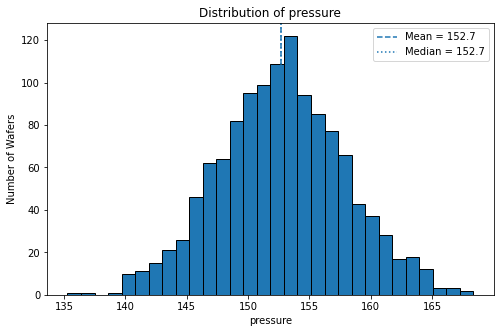

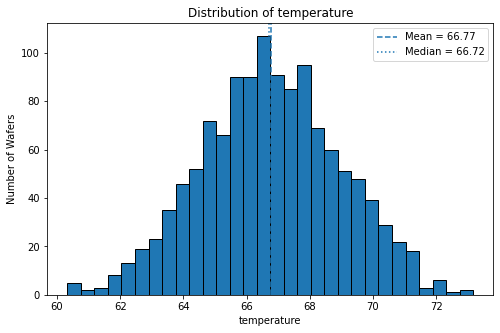

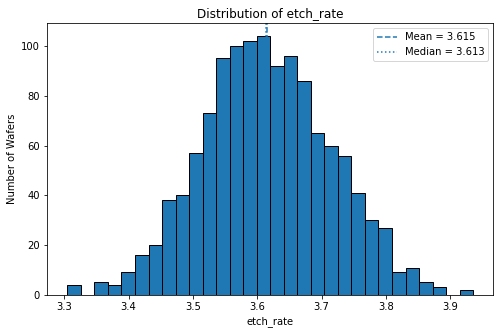

In [15]:
for col in etch_vars:

    plt.figure(figsize=(8, 5))

    plt.hist(
        df[col].dropna(),
        bins=30,
        edgecolor="black"
    )

    plt.axvline(
        df[col].mean(),
        linestyle="--",
        label=f"Mean = {df[col].mean():.4g}"
    )

    plt.axvline(
        df[col].median(),
        linestyle=":",
        label=f"Median = {df[col].median():.4g}"
    )

    plt.xlabel(col)
    plt.ylabel("Number of Wafers")
    plt.title(f"Distribution of {col}")
    plt.legend()

    plt.show()

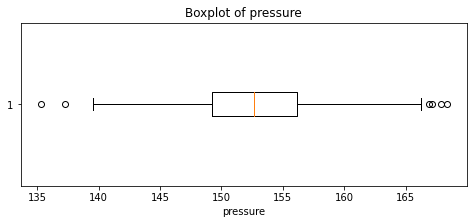

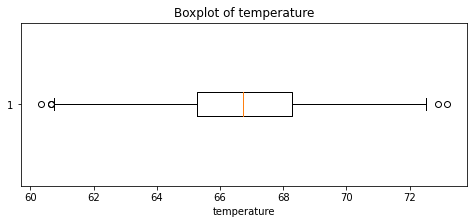

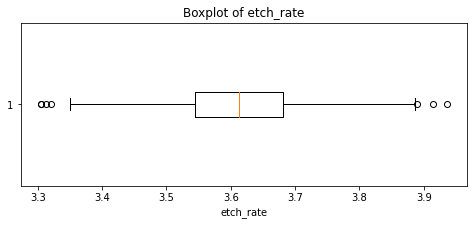

In [16]:
for col in etch_vars:

    plt.figure(figsize=(8, 3))

    plt.boxplot(
        df[col].dropna(),
        vert=False
    )

    plt.xlabel(col)
    plt.title(f"Boxplot of {col}")

    plt.show()

In [17]:
def iqr_flag_summary(df, variables):

    rows = []

    for col in variables:

        s = df[col].dropna()

        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)

        iqr = q3 - q1

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        flag = (
            (s < lower)
            | (s > upper)
        )

        rows.append({
            "variable": col,
            "lower_iqr_fence": lower,
            "upper_iqr_fence": upper,
            "flagged_wafers": flag.sum(),
            "flagged_pct": flag.mean() * 100
        })

    return pd.DataFrame(rows)

In [18]:
etch_iqr_flags = iqr_flag_summary(
    df,
    etch_vars
)

etch_iqr_flags

,variable,lower_iqr_fence,upper_iqr_fence,flagged_wafers,flagged_pct
0,pressure,138.841699,166.551341,6,0.480000
1,temperature,60.730981,72.819736,5,0.400000
2,etch_rate,3.339280,3.887414,7,0.560000


In [19]:
def inspect_iqr_flags(
    df,
    variables,
    context_cols
):

    for col in variables:

        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)

        iqr = q3 - q1

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        flagged = df[
            (df[col] < lower)
            | (df[col] > upper)
        ][
            context_cols + [col]
        ]

        print(
            f"\n{col}: "
            f"{len(flagged)} flagged wafers"
        )

        display(flagged)

In [20]:
etch_context = [
    "lot_id",
    "wafer_id",
    "product_type",
    "technology_node",
    "etch_tool"
]

inspect_iqr_flags(
    df,
    etch_vars,
    etch_context
)


pressure: 6 flagged wafers


,lot_id,wafer_id,product_type,technology_node,etch_tool,pressure
5,LOT_0001,W006,CPU,10nm,ETCH_02,137.224120
455,LOT_0019,W006,ASIC,22nm,ETCH_05,135.292927
678,LOT_0028,W004,FPGA,22nm,ETCH_02,166.922989
958,LOT_0039,W009,GPU,14nm,ETCH_04,167.860784
1031,LOT_0042,W007,CPU,10nm,ETCH_04,167.108574
1171,LOT_0047,W022,FPGA,7nm,ETCH_02,168.342924



temperature: 5 flagged wafers


,lot_id,wafer_id,product_type,technology_node,etch_tool,temperature
130,LOT_0006,W006,ASIC,28nm,ETCH_01,60.328505
237,LOT_0010,W013,Memory,10nm,ETCH_03,60.655562
246,LOT_0010,W022,Memory,10nm,ETCH_03,60.650366
441,LOT_0018,W017,CPU,10nm,ETCH_02,72.883317
760,LOT_0031,W011,GPU,28nm,ETCH_02,73.171970



etch_rate: 7 flagged wafers


,lot_id,wafer_id,product_type,technology_node,etch_tool,etch_rate
154,LOT_0007,W005,Memory,28nm,ETCH_03,3.320934
176,LOT_0008,W002,CPU,10nm,ETCH_03,3.305644
389,LOT_0016,W015,FPGA,28nm,ETCH_03,3.304931
928,LOT_0038,W004,GPU,10nm,ETCH_05,3.313128
950,LOT_0039,W001,GPU,14nm,ETCH_04,3.915055
1102,LOT_0045,W003,CPU,7nm,ETCH_05,3.888908
1167,LOT_0047,W018,FPGA,7nm,ETCH_02,3.935599


In [21]:
for col in etch_vars:

    print(f"\n{col}")

    print("Minimum:", df[col].min())
    print("Maximum:", df[col].max())

    print(
        "Negative values:",
        (df[col] < 0).sum()
    )

    print(
        "Zero values:",
        (df[col] == 0).sum()
    )


pressure
Minimum: 135.29292729351727
Maximum: 168.34292446831336
Negative values: 0
Zero values: 0

temperature
Minimum: 60.32850452196624
Maximum: 73.17197024845848
Negative values: 0
Zero values: 0

etch_rate
Minimum: 3.3049307766857243
Maximum: 3.935598504053312
Negative values: 0
Zero values: 0


### Etch Characterization 

- `pressure`, `temperature`, and `etch_rate` exhibit approximately
  symmetric, unimodal aggregate distributions.

- Mean and median are very similar for all three variables, and
  skewness is close to zero:
   
- Pressure is centered near 152.70 with SD ≈ 5.15 and
  IQR ≈ 6.93.

- Temperature is centered near 66.77 with SD ≈ 2.19 and
  IQR ≈ 3.02.

- Etch rate is centered near 3.615 with SD ≈ 0.100 and
  IQR ≈ 0.137.

## Deposition


In [22]:
deposition_vars = [
    "deposition_rate",
    "thickness_uniformity"
]

deposition_characterization = characterize_variables(
    df,
    deposition_vars
)

deposition_characterization

,variable,n,mean,median,std,q1,q3,iqr,min,max,skewness,iqr_flag_count,iqr_flag_pct
0,deposition_rate,1250,1.899942,1.900440,0.116487,1.827348,1.979659,0.152311,1.542779,2.259813,-0.053169,10,0.800000
1,thickness_uniformity,1250,1.702233,1.700894,0.236905,1.534593,1.864622,0.330029,0.875049,2.456949,0.098773,8,0.640000


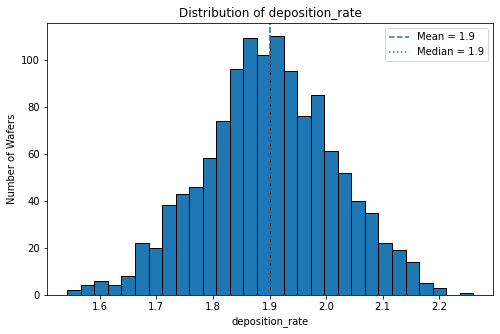

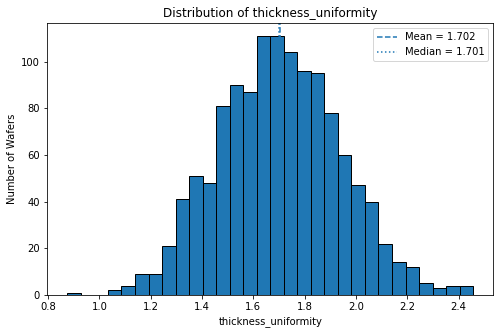

In [23]:
for col in deposition_vars:

    plt.figure(figsize=(8, 5))

    plt.hist(
        df[col].dropna(),
        bins=30,
        edgecolor="black"
    )

    plt.axvline(
        df[col].mean(),
        linestyle="--",
        label=f"Mean = {df[col].mean():.4g}"
    )

    plt.axvline(
        df[col].median(),
        linestyle=":",
        label=f"Median = {df[col].median():.4g}"
    )

    plt.xlabel(col)
    plt.ylabel("Number of Wafers")
    plt.title(f"Distribution of {col}")
    plt.legend()

    plt.show()

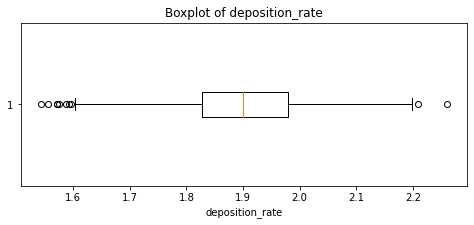

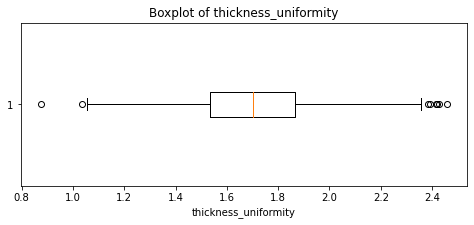

In [24]:
for col in deposition_vars:

    plt.figure(figsize=(8, 3))

    plt.boxplot(
        df[col].dropna(),
        vert=False
    )

    plt.xlabel(col)
    plt.title(f"Boxplot of {col}")

    plt.show()

In [25]:
deposition_iqr_flags = iqr_flag_summary(
    df,
    deposition_vars
)

deposition_iqr_flags

,variable,lower_iqr_fence,upper_iqr_fence,flagged_wafers,flagged_pct
0,deposition_rate,1.598882,2.208125,10,0.800000
1,thickness_uniformity,1.039550,2.359666,8,0.640000


In [26]:
deposition_context = [
    "lot_id",
    "wafer_id",
    "product_type",
    "technology_node",
    "deposition_tool"
]

inspect_iqr_flags(
    df,
    deposition_vars,
    deposition_context
)


deposition_rate: 10 flagged wafers


,lot_id,wafer_id,product_type,technology_node,deposition_tool,deposition_rate
51,LOT_0003,W002,CPU,10nm,DEP_02,2.208251
353,LOT_0015,W004,ASIC,10nm,DEP_01,1.595245
421,LOT_0017,W022,Memory,10nm,DEP_01,2.259813
1020,LOT_0041,W021,GPU,22nm,DEP_01,1.542779
1054,LOT_0043,W005,ASIC,14nm,DEP_01,1.555847
1063,LOT_0043,W014,ASIC,14nm,DEP_01,1.571522
1071,LOT_0043,W022,ASIC,14nm,DEP_01,1.570531
1146,LOT_0046,W022,GPU,7nm,DEP_01,1.587712
1226,LOT_0050,W002,Memory,10nm,DEP_01,1.592804
1236,LOT_0050,W012,Memory,10nm,DEP_01,1.575218



thickness_uniformity: 8 flagged wafers


,lot_id,wafer_id,product_type,technology_node,deposition_tool,thickness_uniformity
143,LOT_0006,W019,ASIC,28nm,DEP_01,0.875049
546,LOT_0022,W022,Memory,28nm,DEP_03,1.033487
997,LOT_0040,W023,FPGA,7nm,DEP_01,2.385028
1061,LOT_0043,W012,ASIC,14nm,DEP_01,2.393170
1127,LOT_0046,W003,GPU,7nm,DEP_01,2.427512
1155,LOT_0047,W006,FPGA,7nm,DEP_01,2.416056
1182,LOT_0048,W008,GPU,28nm,DEP_03,2.419747
1233,LOT_0050,W009,Memory,10nm,DEP_01,2.456949


### Deposition Characterization 

- `deposition_rate` and `thickness_uniformity` exhibit approximately
  symmetric and unimodal aggregate distributions.

- `deposition_rate` has mean ≈ 1.8999 and median ≈ 1.9004.
  Its skewness (-0.053) is close to zero.

- `thickness_uniformity` has mean ≈ 1.7022 and median ≈ 1.7009.
  Its skewness (0.099) indicates only slight positive skew.

- IQR screening identified:
    - 10 deposition-rate observations (0.80%)
    - 8 thickness-uniformity observations (0.64%)

## Ion Implantation


In [27]:
implant_vars = [
    "implant_energy",
    "tilt_angle",
    "dose"
]

implant_characterization = characterize_variables(
    df,
    implant_vars
)

implant_characterization




,variable,n,mean,median,std,q1,q3,iqr,min,max,skewness,iqr_flag_count,iqr_flag_pct
0,implant_energy,1250,49.986779,49.975520,0.998741,49.289898,50.684044,1.394146,47.045751,53.806717,0.022719,5,0.400000
1,tilt_angle,1250,7.001714,7.000520,0.498059,6.667923,7.344025,0.676102,5.462945,8.471524,0.040810,6,0.480000
2,dose,1250,1000095189102549.375000,999968333617684.250000,9896583202945.634766,993097931989915.500000,1006630699552658.125000,13532767562742.625000,970332469312592.750000,1033009718943015.250000,0.082201,8,0.640000


In [28]:
implant_iqr_flags = iqr_flag_summary(
    df,
    implant_vars
)
implant_iqr_flags

,variable,lower_iqr_fence,upper_iqr_fence,flagged_wafers,flagged_pct
0,implant_energy,47.198680,52.775263,5,0.400000
1,tilt_angle,5.653771,8.358177,6,0.480000
2,dose,972798780645801.500000,1026929850896772.000000,8,0.640000


In [29]:
implant_context = [
    "lot_id",
    "wafer_id",
    "product_type",
    "technology_node",
    "implant_tool"
]

inspect_iqr_flags(
    df,
    implant_vars,
    implant_context
)


implant_energy: 5 flagged wafers


,lot_id,wafer_id,product_type,technology_node,implant_tool,implant_energy
139,LOT_0006,W015,ASIC,28nm,IMP_03,53.061947
372,LOT_0015,W023,ASIC,10nm,IMP_03,47.045751
765,LOT_0031,W016,GPU,28nm,IMP_03,53.489648
989,LOT_0040,W015,FPGA,7nm,IMP_01,47.148832
1069,LOT_0043,W020,ASIC,14nm,IMP_01,53.806717



tilt_angle: 6 flagged wafers


,lot_id,wafer_id,product_type,technology_node,implant_tool,tilt_angle
293,LOT_0012,W019,Memory,28nm,IMP_01,8.416748
335,LOT_0014,W011,FPGA,14nm,IMP_03,5.573528
374,LOT_0015,W025,ASIC,10nm,IMP_03,8.471524
938,LOT_0038,W014,GPU,10nm,IMP_02,8.423505
1001,LOT_0041,W002,GPU,22nm,IMP_02,8.437895
1201,LOT_0049,W002,ASIC,28nm,IMP_01,5.462945



dose: 8 flagged wafers


,lot_id,wafer_id,product_type,technology_node,implant_tool,dose
300,LOT_0013,W001,CPU,14nm,IMP_01,971004861201315.250000
303,LOT_0013,W004,CPU,14nm,IMP_01,1032401391486368.000000
329,LOT_0014,W005,FPGA,14nm,IMP_03,1028611365676336.750000
424,LOT_0017,W025,Memory,10nm,IMP_01,1026983288359370.750000
592,LOT_0024,W018,FPGA,28nm,IMP_01,970332469312592.750000
695,LOT_0028,W021,FPGA,22nm,IMP_02,1033009718943015.250000
986,LOT_0040,W012,FPGA,7nm,IMP_01,1027832351422473.250000
1049,LOT_0042,W025,CPU,10nm,IMP_02,1027038751925892.250000


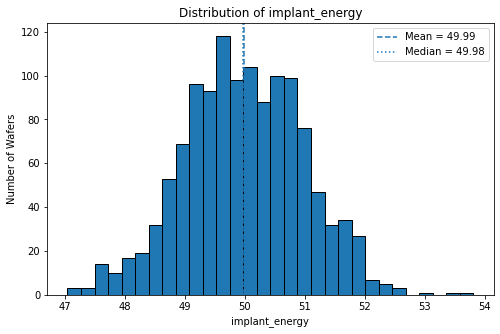

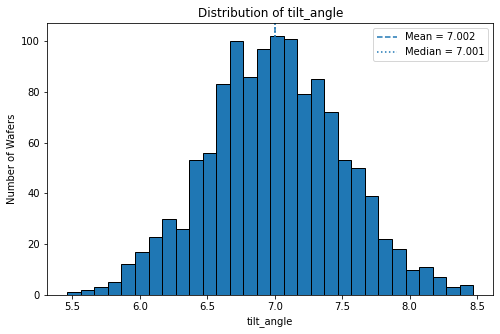

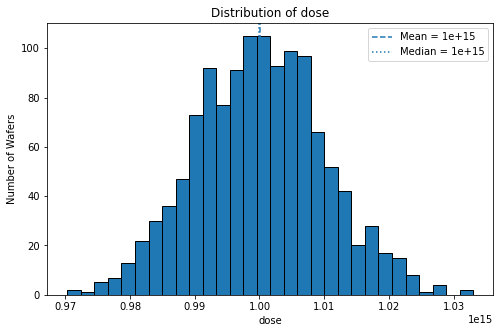

In [30]:
for col in implant_vars:

    plt.figure(figsize=(8, 5))

    plt.hist(
        df[col].dropna(),
        bins=30,
        edgecolor="black"
    )

    plt.axvline(
        df[col].mean(),
        linestyle="--",
        label=f"Mean = {df[col].mean():.4g}"
    )

    plt.axvline(
        df[col].median(),
        linestyle=":",
        label=f"Median = {df[col].median():.4g}"
    )

    plt.xlabel(col)
    plt.ylabel("Number of Wafers")
    plt.title(f"Distribution of {col}")
    plt.legend()

    plt.show()

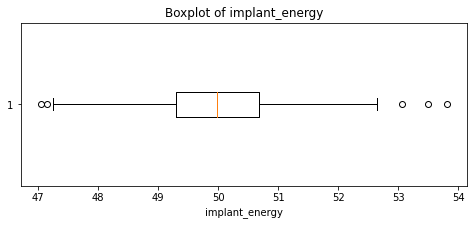

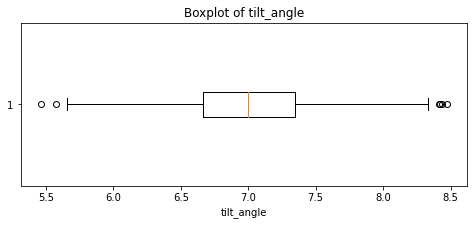

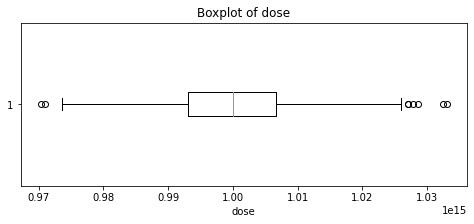

In [31]:
for col in implant_vars:

    plt.figure(figsize=(8, 3))

    plt.boxplot(
        df[col].dropna(),
        vert=False
    )

    plt.xlabel(col)
    plt.title(f"Boxplot of {col}")

    plt.show()

### Ion Implantation Characterization

- `implant_energy`, `tilt_angle`, and `dose` show broadly unimodal,
  approximately symmetric aggregate distributions.

- Mean and median appear closely aligned across the implantation
  variables. Numerical skewness is used to quantify any minor
  asymmetry rather than relying solely on visual interpretation.

- A small number of observations occur beyond the 1.5×IQR fences.


## Metrology


In [32]:
metrology_vars = [
    "critical_dimension",
    "oxide_thickness",
    "resistivity"
]

metrology_characterization = characterize_variables(
    df,
    metrology_vars
)

metrology_characterization

,variable,n,mean,median,std,q1,q3,iqr,min,max,skewness,iqr_flag_count,iqr_flag_pct
0,critical_dimension,1250,24.608270,24.994991,4.245067,21.255550,28.109128,6.853578,15.337494,34.232696,-0.172677,0,0.000000
1,oxide_thickness,1250,56.984467,57.351614,4.654281,53.716388,60.409474,6.693087,44.595515,70.808496,-0.159461,1,0.080000
2,resistivity,1250,2.495853,2.494975,0.299258,2.289884,2.690423,0.400539,1.546989,3.528673,0.087898,14,1.120000


In [33]:
metrology_iqr_flags = iqr_flag_summary(
    df,
    metrology_vars
)

metrology_iqr_flags

,variable,lower_iqr_fence,upper_iqr_fence,flagged_wafers,flagged_pct
0,critical_dimension,10.975183,38.389496,0,0.000000
1,oxide_thickness,43.676758,70.449104,1,0.080000
2,resistivity,1.689075,3.291231,14,1.120000


In [34]:
metrology_context = [
    "lot_id",
    "wafer_id",
    "product_type",
    "technology_node"
]

inspect_iqr_flags(
    df,
    metrology_vars,
    metrology_context
)

inspect_iqr_flags


critical_dimension: 0 flagged wafers


,lot_id,wafer_id,product_type,technology_node,critical_dimension



oxide_thickness: 1 flagged wafers


,lot_id,wafer_id,product_type,technology_node,oxide_thickness
1024,LOT_0041,W025,GPU,22nm,70.808496



resistivity: 14 flagged wafers


,lot_id,wafer_id,product_type,technology_node,resistivity
51,LOT_0003,W002,CPU,10nm,3.389503
105,LOT_0005,W006,Memory,14nm,1.650244
234,LOT_0010,W010,Memory,10nm,1.648748
242,LOT_0010,W018,Memory,10nm,1.546989
288,LOT_0012,W014,Memory,28nm,3.347299
377,LOT_0016,W003,FPGA,28nm,3.482920
529,LOT_0022,W005,Memory,28nm,3.375110
594,LOT_0024,W020,FPGA,28nm,1.660011
672,LOT_0027,W023,GPU,10nm,3.528673
703,LOT_0029,W004,ASIC,14nm,3.308647


<function __main__.inspect_iqr_flags(df, variables, context_cols)>

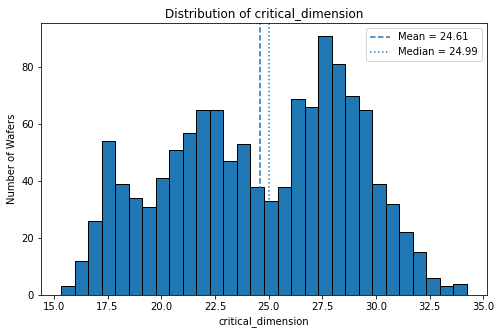

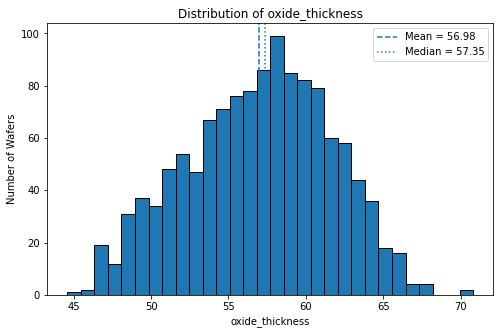

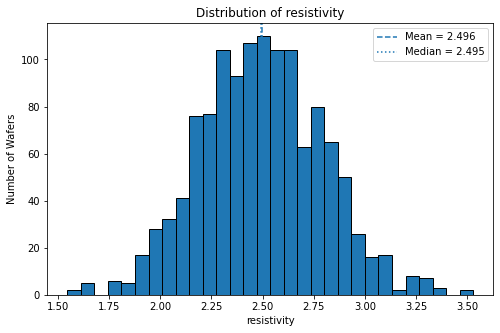

In [35]:
for col in metrology_vars:

    plt.figure(figsize=(8, 5))

    plt.hist(
        df[col].dropna(),
        bins=30,
        edgecolor="black"
    )

    plt.axvline(
        df[col].mean(),
        linestyle="--",
        label=f"Mean = {df[col].mean():.4g}"
    )

    plt.axvline(
        df[col].median(),
        linestyle=":",
        label=f"Median = {df[col].median():.4g}"
    )

    plt.xlabel(col)
    plt.ylabel("Number of Wafers")
    plt.title(f"Distribution of {col}")
    plt.legend()

    plt.show()

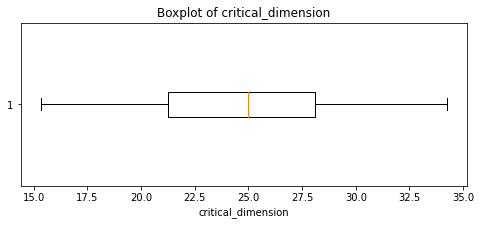

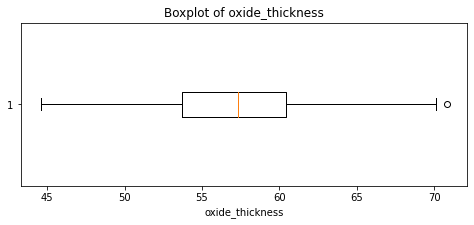

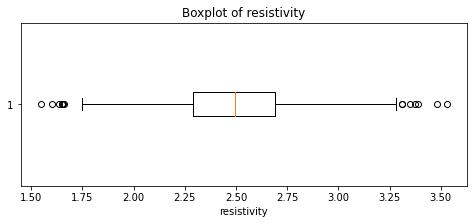

In [36]:
for col in metrology_vars:

    plt.figure(figsize=(8, 3))

    plt.boxplot(
        df[col].dropna(),
        vert=False
    )

    plt.xlabel(col)
    plt.title(f"Boxplot of {col}")

    plt.show()

### Metrology Characterization 

#### Critical Dimension

- `critical_dimension` has mean ≈ 24.61 and median ≈ 24.99,
  with skewness ≈ -0.173.

- `oxide_thickness` is approximately symmetric and unimodal at the
  aggregate level.

- `resistivity` is approximately symmetric and unimodal at the
  aggregate level.

## Defect Inspection


In [37]:
defect_count_summary = pd.Series({
    "n": df["defect_count"].count(),
    "mean": df["defect_count"].mean(),
    "median": df["defect_count"].median(),
    "std": df["defect_count"].std(),
    "variance": df["defect_count"].var(),
    "min": df["defect_count"].min(),
    "q1": df["defect_count"].quantile(0.25),
    "q3": df["defect_count"].quantile(0.75),
    "max": df["defect_count"].max(),
    "skewness": df["defect_count"].skew(),
    "zero_count": (df["defect_count"] == 0).sum(),
    "zero_pct": (df["defect_count"] == 0).mean() * 100
})

defect_count_summary

n            1250.000000
mean          682.777600
median        682.500000
std            87.338157
variance     7627.953701
min           403.000000
q1            623.000000
q3            740.750000
max           993.000000
skewness        0.159312
zero_count      0.000000
zero_pct        0.000000
dtype: float64

In [38]:
defect_frequency = (
    df["defect_count"]
    .value_counts()
    .sort_index()
    .rename_axis("defect_count")
    .reset_index(name="wafer_count")
)

defect_frequency["wafer_pct"] = (
    defect_frequency["wafer_count"] / len(df) * 100
)

defect_frequency

,defect_count,wafer_count,wafer_pct
0,403,1,0.080000
1,433,1,0.080000
2,468,2,0.160000
3,469,1,0.080000
4,472,1,0.080000
...,...,...,...
354,922,1,0.080000
355,923,1,0.080000
356,961,1,0.080000
357,963,1,0.080000


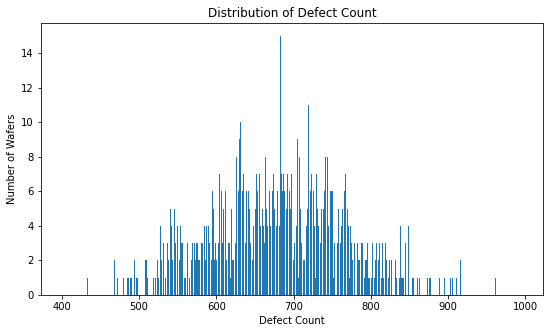

In [39]:
plt.figure(figsize=(9, 5))

plt.bar(
    defect_frequency["defect_count"],
    defect_frequency["wafer_count"]
)

plt.xlabel("Defect Count")
plt.ylabel("Number of Wafers")
plt.title("Distribution of Defect Count")

plt.show()

In [40]:
print("Mean:    ", df["defect_count"].mean())
print("Variance:", df["defect_count"].var())

print(
    "Variance / Mean:",
    df["defect_count"].var() / df["defect_count"].mean()
)

Mean:     682.7776
Variance: 7627.95370120096
Variance / Mean: 11.171944863453282


In [41]:
defect_density_characterization = characterize_variables(
    df,
    ["defect_density"]
)

defect_density_characterization

,variable,n,mean,median,std,q1,q3,iqr,min,max,skewness,iqr_flag_count,iqr_flag_pct
0,defect_density,1250,0.964839,0.963671,0.119583,0.880522,1.047014,0.166492,0.547276,1.344248,0.100221,9,0.720000


In [42]:
defect_density_iqr = iqr_flag_summary(
    df,
    ["defect_density"]
)

defect_density_iqr

,variable,lower_iqr_fence,upper_iqr_fence,flagged_wafers,flagged_pct
0,defect_density,0.630784,1.296751,9,0.720000


In [43]:
defect_context = [
    "lot_id",
    "wafer_id",
    "product_type",
    "technology_node",
    "defect_count"
]

inspect_iqr_flags(
    df,
    ["defect_density"],
    defect_context
)


defect_density: 9 flagged wafers


,lot_id,wafer_id,product_type,technology_node,defect_count,defect_density
143,LOT_0006,W019,ASIC,28nm,403,0.547276
546,LOT_0022,W022,Memory,28nm,433,0.627948
997,LOT_0040,W023,FPGA,7nm,911,1.305073
1008,LOT_0041,W009,GPU,22nm,910,1.298828
1061,LOT_0043,W012,ASIC,14nm,993,1.312900
1127,LOT_0046,W003,GPU,7nm,922,1.327657
1155,LOT_0047,W006,FPGA,7nm,896,1.327712
1182,LOT_0048,W008,GPU,28nm,923,1.329988
1233,LOT_0050,W009,Memory,10nm,961,1.344248


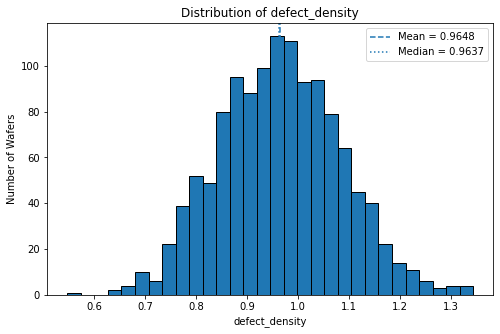

In [44]:
defect_density_vars=["defect_density"]
for col in defect_density_vars:

    plt.figure(figsize=(8, 5))

    plt.hist(
        df[col].dropna(),
        bins=30,
        edgecolor="black"
    )

    plt.axvline(
        df[col].mean(),
        linestyle="--",
        label=f"Mean = {df[col].mean():.4g}"
    )

    plt.axvline(
        df[col].median(),
        linestyle=":",
        label=f"Median = {df[col].median():.4g}"
    )

    plt.xlabel(col)
    plt.ylabel("Number of Wafers")
    plt.title(f"Distribution of {col}")
    plt.legend()

    plt.show()

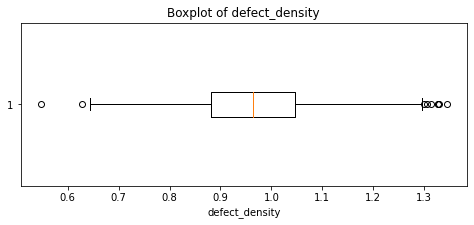

In [45]:
for col in defect_density_vars:

    plt.figure(figsize=(8, 3))

    plt.boxplot(
        df[col].dropna(),
        vert=False
    )

    plt.xlabel(col)
    plt.title(f"Boxplot of {col}")

    plt.show()

### Defect Inspection Characterization 

#### Defect Count

- `defect_count` is a discrete count variable ranging from 403 to 993
  defects per wafer.

- The aggregate distribution is approximately symmetric, with mean
  ≈ 682.78, median ≈ 682.50, and skewness ≈ 0.159.


#### Defect Density

- `defect_density` is approximately symmetric and unimodal at the
  aggregate level.

- Mean ≈ 0.9648 and median ≈ 0.9637, with skewness ≈ 0.100.

## Electrical Test


In [46]:
electrical_vars = [
    "vth",
    "leakage_current",
    "resistance"
]



electrical_characterization = characterize_variables(
    df,
    electrical_vars
)

electrical_characterization



,variable,n,mean,median,std,q1,q3,iqr,min,max,skewness,iqr_flag_count,iqr_flag_pct
0,vth,1250,0.644599,0.643843,0.067599,0.601040,0.691697,0.090658,0.464514,0.867928,0.021858,3,0.240000
1,leakage_current,1250,0.000373,0.000315,0.000238,0.000219,0.000461,0.000242,0.000058,0.002538,2.690424,56,4.480000
2,resistance,1250,100.715200,100.616622,6.307770,96.203866,105.004190,8.800324,80.608027,117.936695,-0.010221,2,0.160000


In [47]:
electrical_iqr_flags = iqr_flag_summary(
    df,
    electrical_vars
)

electrical_iqr_flags

,variable,lower_iqr_fence,upper_iqr_fence,flagged_wafers,flagged_pct
0,vth,0.465053,0.827684,3,0.240000
1,leakage_current,-0.000145,0.000825,56,4.480000
2,resistance,83.003380,118.204676,2,0.160000


In [48]:
electrical_context = [
    "lot_id",
    "wafer_id",
    "product_type",
    "technology_node"
]

inspect_iqr_flags(
    df,
    electrical_vars,
    electrical_context
)


vth: 3 flagged wafers


,lot_id,wafer_id,product_type,technology_node,vth
294,LOT_0012,W020,Memory,28nm,0.834033
1059,LOT_0043,W010,ASIC,14nm,0.867928
1152,LOT_0047,W003,FPGA,7nm,0.464514



leakage_current: 56 flagged wafers


,lot_id,wafer_id,product_type,technology_node,leakage_current
10,LOT_0001,W011,CPU,10nm,0.001989
28,LOT_0002,W004,FPGA,22nm,0.000927
31,LOT_0002,W007,FPGA,22nm,0.000982
61,LOT_0003,W012,CPU,10nm,0.000834
64,LOT_0003,W015,CPU,10nm,0.000874
110,LOT_0005,W011,Memory,14nm,0.000846
230,LOT_0010,W006,Memory,10nm,0.000881
259,LOT_0011,W010,GPU,28nm,0.000998
401,LOT_0017,W002,Memory,10nm,0.000914
430,LOT_0018,W006,CPU,10nm,0.000901



resistance: 2 flagged wafers


,lot_id,wafer_id,product_type,technology_node,resistance
667,LOT_0027,W018,GPU,10nm,80.608027
791,LOT_0032,W017,CPU,10nm,80.786589


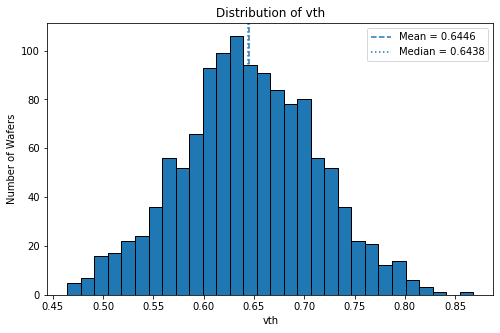

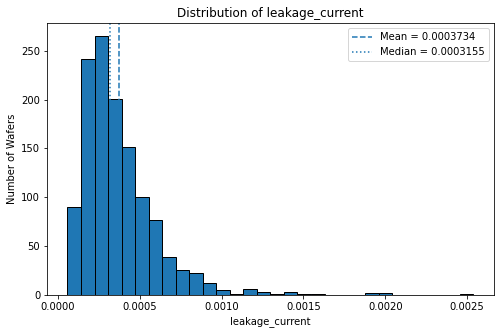

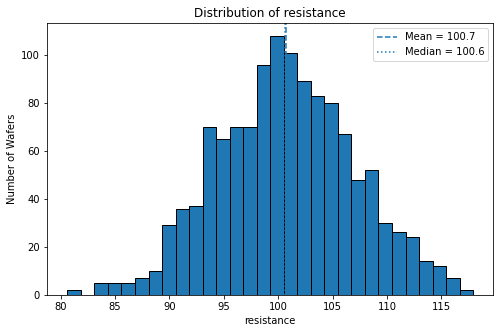

In [49]:

for col in electrical_vars:

    plt.figure(figsize=(8, 5))

    plt.hist(
        df[col].dropna(),
        bins=30,
        edgecolor="black"
    )

    plt.axvline(
        df[col].mean(),
        linestyle="--",
        label=f"Mean = {df[col].mean():.4g}"
    )

    plt.axvline(
        df[col].median(),
        linestyle=":",
        label=f"Median = {df[col].median():.4g}"
    )

    plt.xlabel(col)
    plt.ylabel("Number of Wafers")
    plt.title(f"Distribution of {col}")
    plt.legend()

    plt.show()

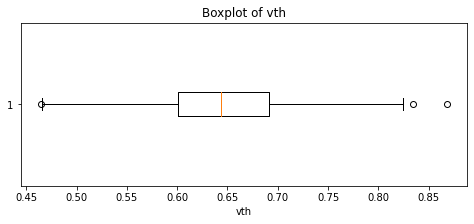

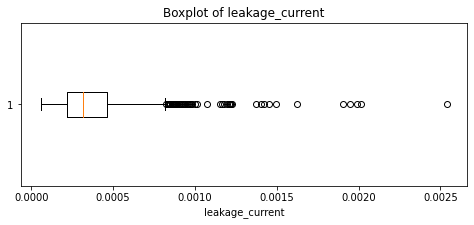

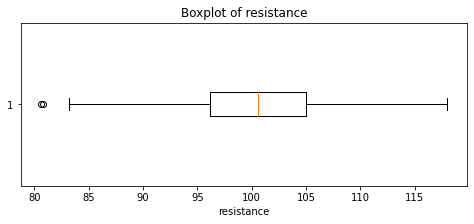

In [50]:
for col in electrical_vars:

    plt.figure(figsize=(8, 3))

    plt.boxplot(
        df[col].dropna(),
        vert=False
    )

    plt.xlabel(col)
    plt.title(f"Boxplot of {col}")

    plt.show()

### Electrical Test Characterization 

- `vth` is approximately symmetric at the aggregate level, with mean
  ≈ 0.6446, median ≈ 0.6438, and skewness ≈ 0.022. Three observations
  (0.24%) were identified by the 1.5×IQR screening rule.

- `resistance` is also approximately symmetric, with mean ≈ 100.72,
  median ≈ 100.62, and skewness ≈ -0.010. Two observations (0.16%)
  were identified by the IQR screening rule.

- `leakage_current` differs substantially from the other electrical
  variables. Its aggregate distribution is strongly positively skewed
  (skewness ≈ 2.69) with a right tail.


## Yield 


In [51]:
yield_summary = pd.Series({
    "n": df["yield"].count(),
    "mean": df["yield"].mean(),
    "median": df["yield"].median(),
    "std": df["yield"].std(),
    "q1": df["yield"].quantile(0.25),
    "q3": df["yield"].quantile(0.75),
    "iqr": df["yield"].quantile(0.75) - df["yield"].quantile(0.25),
    "min": df["yield"].min(),
    "max": df["yield"].max(),
    "skewness": df["yield"].skew()
})

yield_summary

n          1250.000000
mean          0.456679
median        0.415796
std           0.175306
q1            0.323588
q3            0.573955
iqr           0.250367
min           0.148086
max           0.982489
skewness      0.740538
dtype: float64

In [52]:
df["yield"].describe(
    percentiles=[
        0.01, 0.05, 0.10,
        0.25, 0.50, 0.75,
        0.90, 0.95, 0.99
    ]
)

count   1250.000000
mean       0.456679
std        0.175306
min        0.148086
1%         0.200311
5%         0.230708
10%        0.254284
25%        0.323588
50%        0.415796
75%        0.573955
90%        0.720128
95%        0.785936
99%        0.921191
max        0.982489
Name: yield, dtype: float64

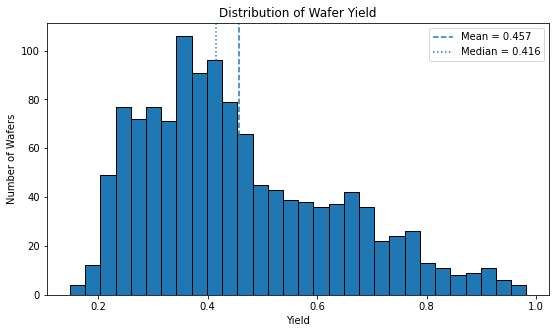

In [53]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(df["yield"], bins=30, edgecolor="black")

ax.axvline(
    df["yield"].mean(),
    linestyle="--",
    label=f"Mean = {df['yield'].mean():.3f}"
)

ax.axvline(
    df["yield"].median(),
    linestyle=":",
    label=f"Median = {df['yield'].median():.3f}"
)

ax.set_xlabel("Yield")
ax.set_ylabel("Number of Wafers")
ax.set_title("Distribution of Wafer Yield")
ax.legend()

plt.show()

In [54]:
q1 = df["yield"].quantile(0.25)
q3 = df["yield"].quantile(0.75)
iqr = q3 - q1

lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr

yield_iqr_flag = (
    (df["yield"] < lower_fence) |
    (df["yield"] > upper_fence)
)

print(f"Q1:          {q1:.6f}")
print(f"Q3:          {q3:.6f}")
print(f"IQR:         {iqr:.6f}")
print(f"Lower fence: {lower_fence:.6f}")
print(f"Upper fence: {upper_fence:.6f}")
print(f"Flagged:     {yield_iqr_flag.sum()}")
print(f"Flagged %:   {yield_iqr_flag.mean() * 100:.2f}%")

Q1:          0.323588
Q3:          0.573955
IQR:         0.250367
Lower fence: -0.051962
Upper fence: 0.949505
Flagged:     5
Flagged %:   0.40%


In [55]:
yield_flagged = df.loc[
    yield_iqr_flag,
    [
        "lot_id",
        "wafer_id",
        "product_type",
        "technology_node",
        "yield"
    ]
].sort_values("yield")

yield_flagged

,lot_id,wafer_id,product_type,technology_node,yield
228,LOT_0010,W004,Memory,10nm,0.950399
438,LOT_0018,W014,CPU,10nm,0.961157
659,LOT_0027,W010,GPU,10nm,0.971861
249,LOT_0010,W025,Memory,10nm,0.978838
357,LOT_0015,W008,ASIC,10nm,0.982489


In [56]:
yield_by_product = (
    df.groupby("product_type")["yield"]
      .agg(["count", "mean", "median", "std", "min", "max"])
      .sort_values("mean")
)

yield_by_product

,count,mean,median,std,min,max
product_type,,,,,,
ASIC,200,0.409427,0.374233,0.157724,0.148086,0.982489
GPU,275,0.430529,0.385967,0.171573,0.149783,0.971861
Memory,225,0.437658,0.410372,0.162580,0.207418,0.978838
FPGA,275,0.454633,0.416654,0.175501,0.149783,0.921320
CPU,275,0.534803,0.519232,0.177292,0.180259,0.961157


In [57]:
yield_by_node = (
    df.groupby("technology_node")["yield"]
      .agg(["count", "mean", "median", "std", "min", "max"])
      .sort_values("mean")
)

yield_by_node

,count,mean,median,std,min,max
technology_node,,,,,,
22nm,125,0.340087,0.337543,0.092096,0.181122,0.617625
14nm,250,0.341871,0.341091,0.092953,0.148086,0.759399
28nm,300,0.344517,0.345662,0.086908,0.149783,0.722464
7nm,200,0.583302,0.568376,0.149311,0.291902,0.924116
10nm,375,0.594279,0.589411,0.158631,0.209680,0.982489


In [58]:
lot_yield = (
    df.groupby("lot_id")
      .agg(
          wafer_count=("wafer_id", "count"),
          mean_yield=("yield", "mean"),
          median_yield=("yield", "median"),
          std_yield=("yield", "std"),
          min_yield=("yield", "min"),
          max_yield=("yield", "max")
      )
      .sort_values("mean_yield")
)

lot_yield

,wafer_count,mean_yield,median_yield,std_yield,min_yield,max_yield
lot_id,,,,,,
LOT_0024,25,0.310006,0.284353,0.103252,0.149783,0.664549
LOT_0043,25,0.312320,0.306975,0.081503,0.184416,0.472497
LOT_0048,25,0.313936,0.310344,0.068636,0.214190,0.463536
LOT_0041,25,0.315029,0.310021,0.074997,0.184828,0.448831
LOT_0036,25,0.322703,0.324261,0.074210,0.212953,0.424360
LOT_0039,25,0.324414,0.300206,0.102865,0.155300,0.544317
LOT_0028,25,0.331206,0.317426,0.105963,0.181122,0.617625
LOT_0029,25,0.332698,0.336556,0.111374,0.148086,0.688699
LOT_0025,25,0.332918,0.345683,0.066225,0.221692,0.472108


In [59]:
print("Lowest mean-yield lots:")
display(lot_yield.head(10))

print("\nHighest mean-yield lots:")
display(lot_yield.tail(10))

Lowest mean-yield lots:


,wafer_count,mean_yield,median_yield,std_yield,min_yield,max_yield
lot_id,,,,,,
LOT_0024,25,0.310006,0.284353,0.103252,0.149783,0.664549
LOT_0043,25,0.312320,0.306975,0.081503,0.184416,0.472497
LOT_0048,25,0.313936,0.310344,0.068636,0.214190,0.463536
LOT_0041,25,0.315029,0.310021,0.074997,0.184828,0.448831
LOT_0036,25,0.322703,0.324261,0.074210,0.212953,0.424360
LOT_0039,25,0.324414,0.300206,0.102865,0.155300,0.544317
LOT_0028,25,0.331206,0.317426,0.105963,0.181122,0.617625
LOT_0029,25,0.332698,0.336556,0.111374,0.148086,0.688699
LOT_0025,25,0.332918,0.345683,0.066225,0.221692,0.472108



Highest mean-yield lots:


,wafer_count,mean_yield,median_yield,std_yield,min_yield,max_yield
lot_id,,,,,,
LOT_0010,25,0.582122,0.572696,0.193571,0.247321,0.978838
LOT_0030,25,0.589200,0.576049,0.149582,0.344954,0.924116
LOT_0020,25,0.613660,0.530260,0.173942,0.378390,0.921320
LOT_0032,25,0.617516,0.621589,0.120326,0.427652,0.908002
LOT_0015,25,0.625297,0.608735,0.164314,0.275502,0.982489
LOT_0003,25,0.633716,0.616457,0.167213,0.394165,0.943781
LOT_0026,25,0.634528,0.636792,0.155655,0.352089,0.913891
LOT_0027,25,0.659618,0.626929,0.151738,0.405519,0.971861
LOT_0008,25,0.665173,0.723134,0.153685,0.309568,0.846272
